#### By: Peyman Shahidi
#### Created: Aug 21, 2026

<br>

Execution mode of the middle step in the local block of Proposition 1, as a function of the predecessor's and the middle step's success probabilities.

Panel (a):


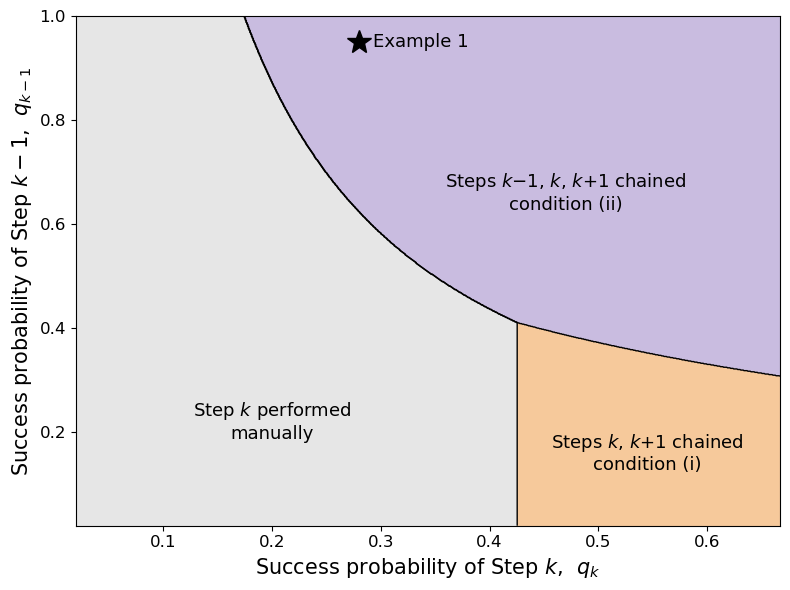

  manual               optimal on  47.7% of the grid
  chain {k,k+1}        optimal on  12.7% of the grid
  chain {k-1,k,k+1}    optimal on  39.6% of the grid
  chain {k-1,k}        optimal on   0.0% of the grid
Panel (b):


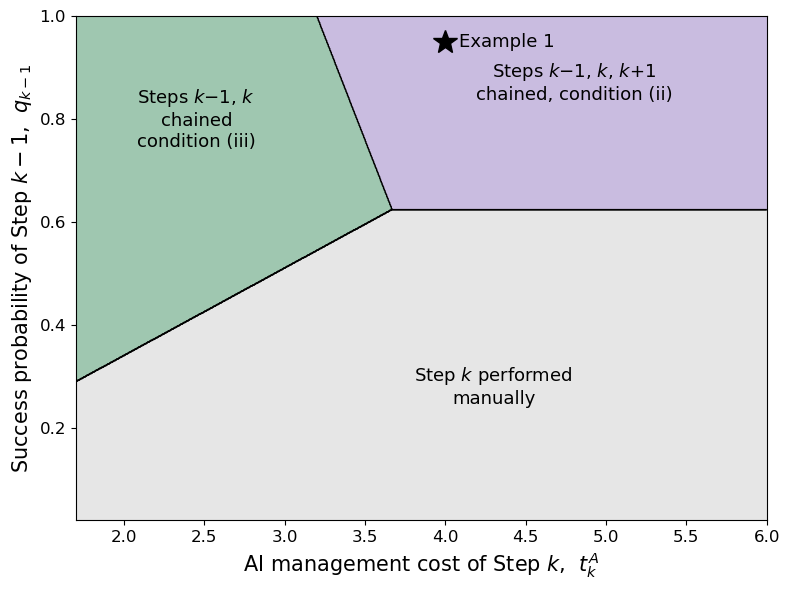

  manual               optimal on  53.8% of the grid
  chain {k,k+1}        optimal on   0.0% of the grid
  chain {k-1,k,k+1}    optimal on  22.9% of the grid
  chain {k-1,k}        optimal on  23.3% of the grid


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import os

main_folder_path = ".."
output_plot_path = f"{main_folder_path}/writeup/plots"
os.makedirs(output_plot_path, exist_ok=True)

# How the cost-minimizing arrangement of the block {k-1, k, k+1} executes the middle
# step k, over two slices of the parameter space. Everything not on an axis is fixed at
# the values of Example 1 of Section 4.1: an expensive but AI-reliable predecessor, an
# AI-hard middle step on which the human holds the comparative advantage throughout,
# and an AI-easy endpoint executed as a standalone augmented step.
tM_p, tA_p = 15.0, 15.0          # step k-1: manual cost, AI management cost
tM_k, tA_k0, qk0 = 6.0, 4.0, 0.28  # step k  : manual cost, AI management cost, success probability
tM_n, tA_n, q_n = 8.0, 4.0, 0.9  # step k+1: manual cost, AI management cost, success probability

v_n = min(tM_n, tA_n / q_n)      # standalone cost of the endpoint

LABEL_FS, TICK_FS, REGION_FS = 15, 12, 13
COLORS = ["#e6e6e6", "#f6c99b", "#c9bce0", "#9fc7b0"]   # manual, (i), (ii), (iii)
NAMES  = ["manual", "chain {k,k+1}", "chain {k-1,k,k+1}", "chain {k-1,k}"]


def arrangement_costs(QP, QK, TA_K):
    """Cost of each feasible arrangement of the block, given grids of parameters."""
    v_p = np.minimum(tM_p, tA_p / QP)
    return np.stack([
        v_p + tM_k + v_n,                 # step k manual, neighbours on their own
        v_p + tA_n / (QK * q_n),          # steps k, k+1 chained        -> condition (i)
        tA_n / (QP * QK * q_n),           # steps k-1, k, k+1 chained   -> condition (ii)
        TA_K / (QP * QK) + v_n,           # steps k-1, k chained        -> condition (iii)
    ])


def region_plot(X, Y, best, xlabel, ylabel, labels, star, fname):
    plt.figure(figsize=(8, 6))
    plt.pcolormesh(X, Y, best, cmap=ListedColormap(COLORS), vmin=-0.5, vmax=3.5, shading="auto")
    plt.contour(X, Y, best, levels=[0.5, 1.5, 2.5], colors="black", linewidths=1)
    for (x, y, text) in labels:
        plt.text(x, y, text, ha="center", va="center", fontsize=REGION_FS)
    plt.plot(*star, marker="*", markersize=18, color="black")
    plt.text(star[0] + 0.02 * (X.max() - X.min()), star[1], "Example 1", fontsize=REGION_FS, va="center")
    plt.xlabel(xlabel, fontsize=LABEL_FS)
    plt.ylabel(ylabel, fontsize=LABEL_FS)
    plt.xlim(X.min(), X.max())
    plt.ylim(Y.min(), Y.max())
    plt.tick_params(labelsize=TICK_FS)
    plt.tight_layout()
    plt.savefig(f"{output_plot_path}/{fname}", dpi=300)
    plt.show()
    for i, n in enumerate(NAMES):
        print(f"  {n:20s} optimal on {100*(best == i).mean():5.1f}% of the grid")


# ---------- Panel (a): the two success probabilities, with tA_k fixed ----------
# The human holds the comparative advantage on step k whenever tM_k < tA_k / q_k, that is
# for q_k below tA_k / tM_k = 2/3, which is where the horizontal axis stops.
qk = np.linspace(0.02, tA_k0 / tM_k, 900)
qp = np.linspace(0.02, 1.0, 900)
QK, QP = np.meshgrid(qk, qp)
best_a = np.argmin(arrangement_costs(QP, QK, tA_k0), axis=0)

print("Panel (a):")
region_plot(
    QK, QP, best_a,
    r"Success probability of Step $k$,  $q_k$",
    r"Success probability of Step $k-1$,  $q_{k-1}$",
    [(0.20, 0.22, "Step $k$ performed\nmanually"),
     (0.545, 0.16, "Steps $k$, $k{+}1$ chained\ncondition (i)"),
     (0.47, 0.66, "Steps $k{-}1$, $k$, $k{+}1$ chained\ncondition (ii)")],
    (qk0, 0.95), "ca_regions_reliability.png",
)

# ---------- Panel (b): step k's own AI management cost, with q_k fixed ----------
# Below tA_k = q_k * tM_k the AI holds the comparative advantage on step k in isolation,
# so the horizontal axis starts there.
ta = np.linspace(qk0 * tM_k + 0.02, 6.0, 900)
TA, QP2 = np.meshgrid(ta, qp)
best_b = np.argmin(arrangement_costs(QP2, qk0, TA), axis=0)

print("Panel (b):")
region_plot(
    TA, QP2, best_b,
    r"AI management cost of Step $k$,  $t^A_k$",
    r"Success probability of Step $k-1$,  $q_{k-1}$",
    [(4.3, 0.28, "Step $k$ performed\nmanually"),
     (2.45, 0.80, "Steps $k{-}1$, $k$\nchained\ncondition (iii)"),
     (4.8, 0.87, "Steps $k{-}1$, $k$, $k{+}1$\nchained, condition (ii)")],
    (tA_k0, 0.95), "ca_regions_mgmtcost.png",
)
